In [1]:
#Imports
import sys,os
#os.environ['MKL_NUM_THREADS'] = '4' # set number of MKL threads to run in parallel
from quspin.operators import hamiltonian,quantum_operator
from quspin.basis import spin_basis_1d
from numpy.random import uniform,seed
from joblib import delayed,Parallel
from itertools import combinations
from functools import partial
import numpy as np
import gc
import pickle
from time import time
from quspin.tools.measurements import diag_ensemble
from quspin.tools.evolution import ED_state_vs_time
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot, show, figure, xlabel, ylabel, xscale, yscale, legend, loglog, imshow, scatter
from numpy import pi, exp, log, sin , cos, tan, log, array
import quspin


In [2]:
###### Model parameters
proj_config= "11111111"
config = "11111111"
#Length of chain
L = 10
#Projection
op = "x"
#Create Basis
basis = spin_basis_1d(L, pauli = -1)


In [4]:
#Create Hamiltonian
J1, J2, h0 = 1, 0, 1
#NN Sigma x term (Periodic Boundary Conditions)
NN_sigma_x = [ [-J1, i, (i+1)%L] for i in range(L)]
NNN_sigma_x = [ [-J2, i, (i+2)%L] for i in range(L)]

#site coupling lists
sigma_z = [ [-1, i] for i in range(L)]
#Define the static H (that doesn't change)
static_H = [ ["xx", NN_sigma_x], ["xx",NNN_sigma_x] ] 
#The z field is the quench
Quenching_H = [["z", sigma_z]]
#Define operator dictionary
operator_dict = dict(H0= static_H, Quench = Quenching_H)
#Build Hamiltonian
H = quantum_operator(operator_dict, basis=basis, check_herm= False, check_symm = False)
#Define Parameters
params_dict = dict( H0=1, Quench=h0)
#Build H0
H0 = H.tohamiltonian(params_dict)
#Find eigenvalues
E,V = np.linalg.eigh(H0.todense())
#Convert matrix to array
V = np.array(V)
#Ground state of unquenched hamiltonian
V0= V[:,0]
D = len(V0)
H0 = array(H0.todense())

In [ ]:
def thermal_expt(beta,V,E,op):
    Z=0
    expt=  0
    for i,Ei in enumerate(E):
        psi = V[:,i]
        weight = np.exp(-beta*Ei)
        Z+= weight
        expt+= np.vdot(psi, op @ psi)* weight
    return expt/Z

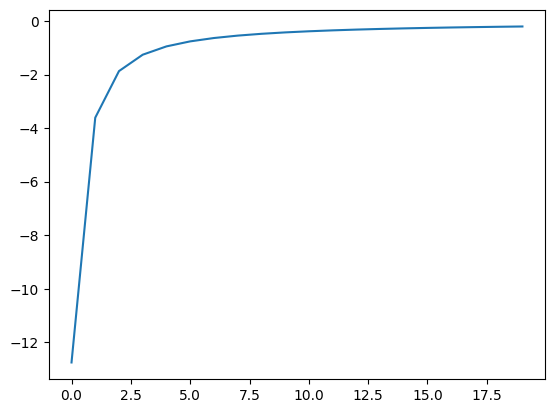

In [16]:
plot([thermal_expt(1/i,V,E,H0) for i in np.linspace(0.1,100,20)])